# *LENNA IMAGE*

In [4]:
#Importing necessarry libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

In [6]:
#reading the image as color image
my_img = cv2.imread("lena.png",1)

In [7]:
#print the matrix
print(my_img)

[[[125 137 226]
  [125 137 226]
  [133 137 223]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 [[125 137 226]
  [125 137 226]
  [133 137 223]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 [[125 137 226]
  [125 137 226]
  [133 137 223]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 ...

 [[ 60  18  84]
  [ 60  18  84]
  [ 58  27  92]
  ...
  [ 84  73 173]
  [ 76  68 172]
  [ 79  62 177]]

 [[ 57  22  82]
  [ 57  22  82]
  [ 62  32  96]
  ...
  [ 79  70 179]
  [ 81  71 181]
  [ 81  74 185]]

 [[ 57  22  82]
  [ 57  22  82]
  [ 62  32  96]
  ...
  [ 79  70 179]
  [ 81  71 181]
  [ 81  74 185]]]


In [9]:
print("Image Dimension(H,W,C) is " , my_img.shape)

Image Dimension(H,W,C) is  (512, 512, 3)


(-0.5, 511.5, 511.5, -0.5)

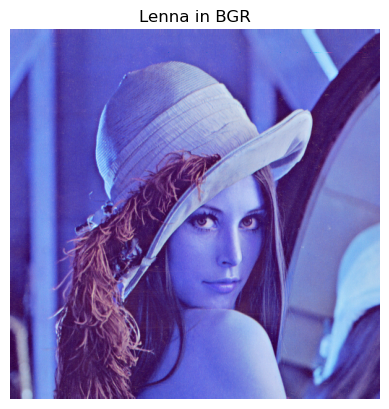

In [9]:
plt.title('Lenna in BGR')
plt.imshow(my_img) #Opencv stores images in BGR format
plt.axis("off")

In [ ]:
#Reading image by IPython
Image(filename = "lena.png")
 

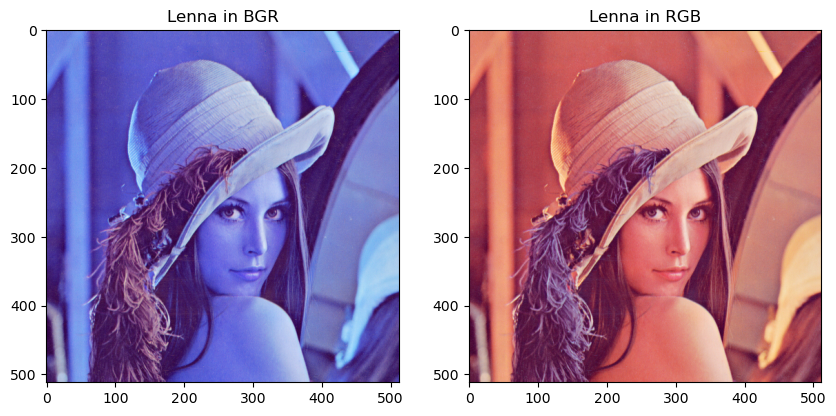

In [11]:

myimg_new = my_img[:,:,::-1] #cv2.cvtColor(my_img,cv2.COLOR_BGR2RGB)

plt.figure(figsize=[10,5])
plt.subplot(121);plt.title('Lenna in BGR');plt.imshow(my_img);
plt.subplot(122);plt.title("Lenna in RGB");plt.imshow(myimg_new); 

**CONVERTING RGB TO GRAY SCALE**

(512, 512)

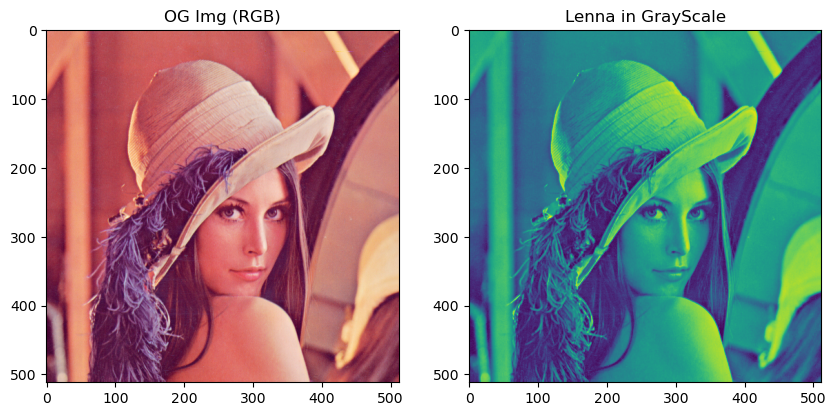

In [15]:
#Converting image from RGB to Grayscale by Opencv function
myimg_gray = cv2.cvtColor(myimg_new,cv2.COLOR_RGB2GRAY)
plt.figure(figsize=[10,5])
plt.axis('off')
plt.subplot(121);plt.title('OG Img (RGB)');plt.imshow(myimg_new);
plt.subplot(122);plt.title("Lenna in GrayScale");plt.imshow(myimg_gray); 
myimg_gray.shape

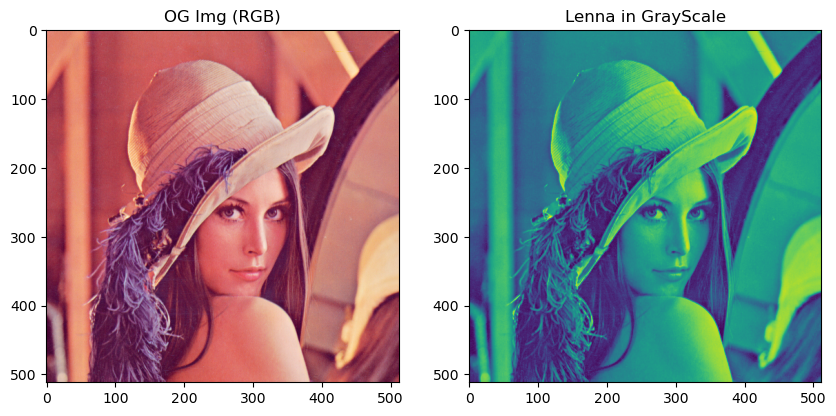

In [19]:
#Converting image from RGB to Grayscale by Mathematically
r,g,b = cv2.split(myimg_new)
grey_img =  (0.299 * r + 0.587 * g + 0.114 * b)
plt.figure(figsize=[10,5])
plt.subplot(121);plt.title('OG Img (RGB)');plt.imshow(myimg_new);
plt.subplot(122);plt.title("Lenna in GrayScale");plt.imshow(grey_img)


In [17]:
print("DImension of Grayscale image ", myimg_gray.shape)

DImension of Grayscale image  (512, 512)


In [ ]:
#Saving the gray scale images
cv2.imwrite('greyLenna.png', myimg_gray)

**RESIZING by builtin**

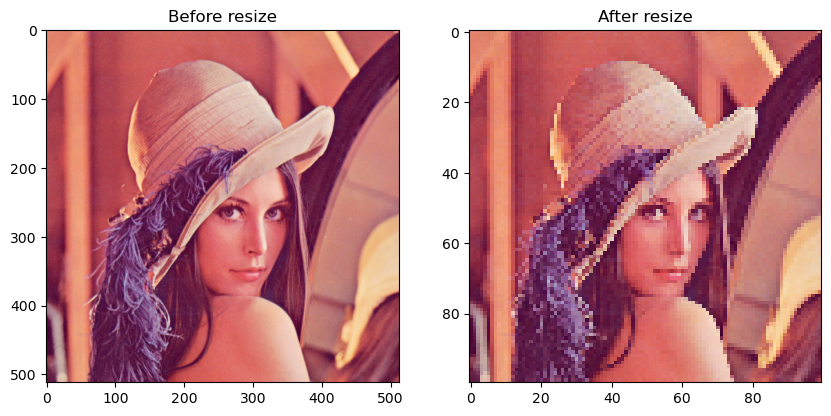

In [21]:
res_img= cv2.resize(myimg_new,(100,100))

plt.figure(figsize=[10,5])
plt.subplot(121)
plt.title('Before resize')
plt.imshow(myimg_new)
plt.subplot(122)
plt.title('After resize')
plt.imshow(res_img)

In [23]:
print('Resized Dimension',res_img.shape)
cv2.imwrite('resizeLenna.png', res_img)

Resized Dimension (100, 100, 3)


True

****IMAGE HISTOGRAM OF LENNA GRAYSCALE****

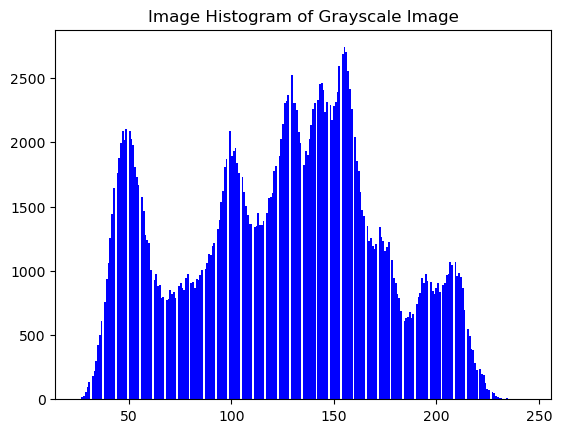

In [14]:
plt.title('Image Histogram of Grayscale Image')
plt.hist(myimg_gray.ravel(),bins=256,color='blue') #sns.histplot(myimg_gray.flatten())
plt.show()

**HISTOGRAM EQUILIZATION By Builtin**

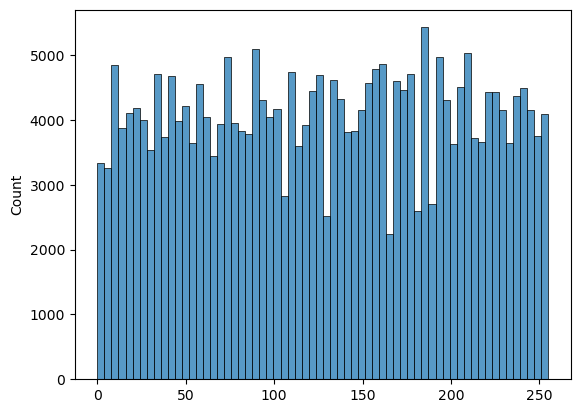

In [20]:
import seaborn as sns
equ = cv2.equalizeHist(myimg_gray)
sns.histplot(equ.flatten())
plt.show()

<Axes: title={'center': 'After Equalize'}, ylabel='Count'>

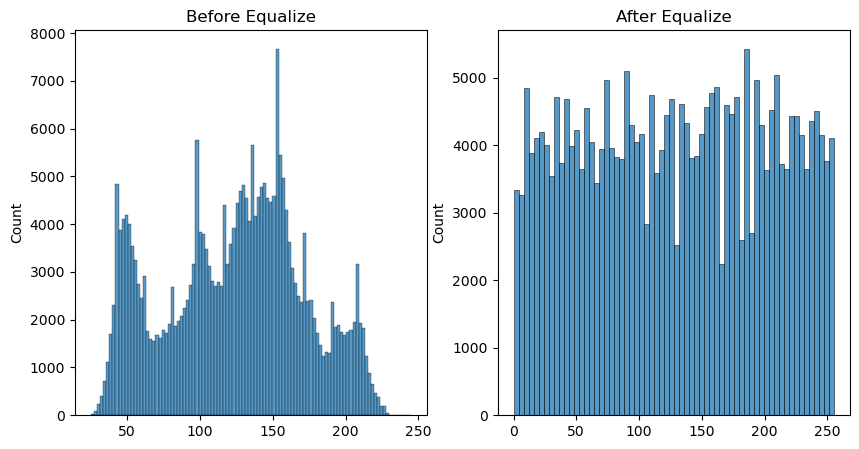

In [21]:
plt.figure(figsize=[10,5])
plt.subplot(121);plt.title('Before Equalize');sns.histplot(myimg_gray.flatten())
plt.subplot(122);plt.title('After Equalize');sns.histplot(equ.flatten())
 

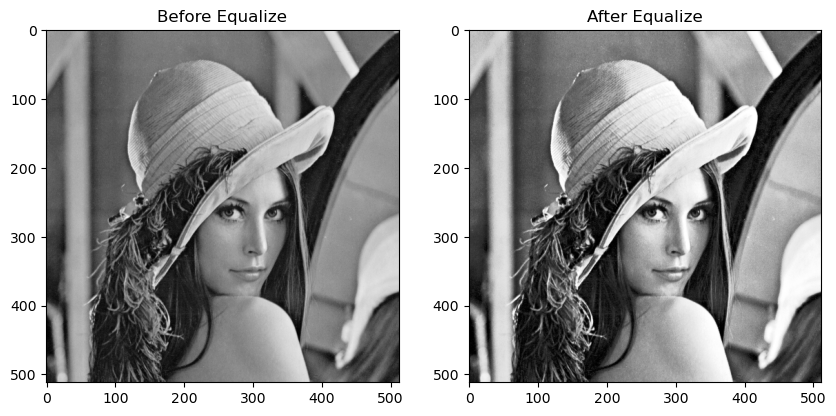

In [24]:
plt.figure(figsize=[10,5])
plt.subplot(121);plt.title('Before Equalize');plt.imshow(myimg_gray,cmap='gray')
plt.subplot(122);plt.title('After Equalize');plt.imshow(equ,cmap='gray')


***HISTOGRAM EQUILIZATION BY MANUAL***

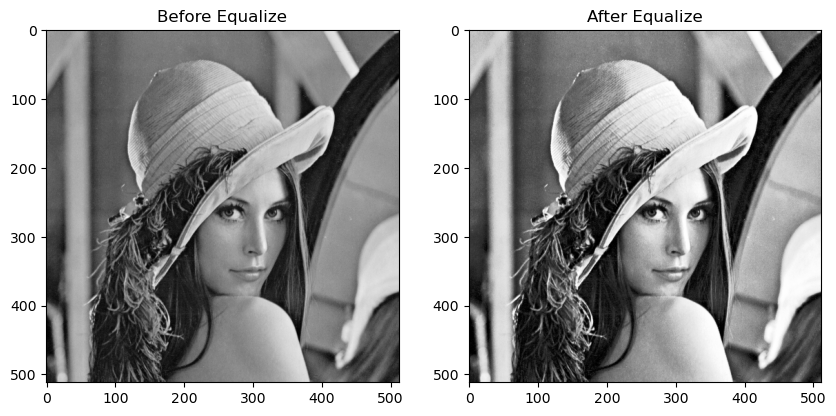

In [48]:
import numpy as np
histg,bins = np.histogram(myimg_gray.flatten(),bins=256,range=[0,256])

#FInding cdf
cdf = histg.cumsum()
cdf_norm = (cdf-cdf.min())*255 / (cdf.max() - cdf.min())
cdf_norm = cdf_norm.astype('uint8')

#Map og values to new
equ_m = cdf_norm[myimg_gray]
plt.figure(figsize=[10,5])
plt.subplot(121);plt.title('Before Equalize');plt.imshow(myimg_gray,cmap='gray')
plt.subplot(122);plt.title('After Equalize');plt.imshow(equ_m,cmap='gray')


<Axes: title={'center': 'After Equalize'}, ylabel='Count'>

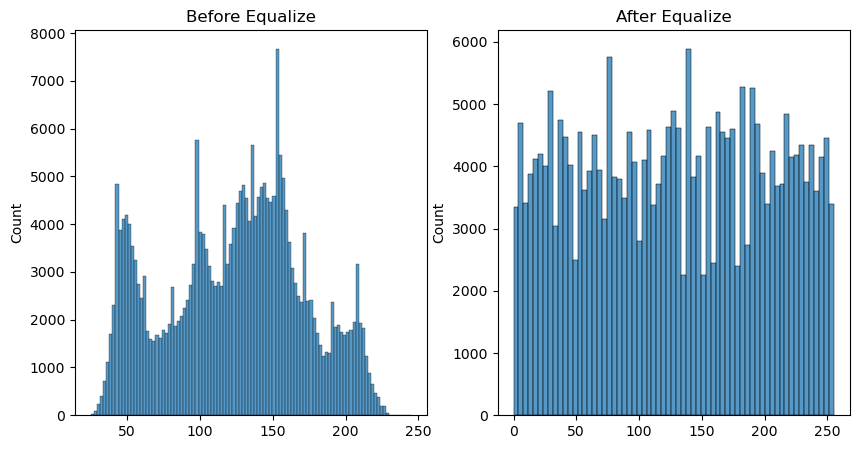

In [50]:
plt.figure(figsize=[10,5])
plt.subplot(121);plt.title('Before Equalize');sns.histplot(myimg_gray.flatten())
plt.subplot(122);plt.title('After Equalize');sns.histplot(equ_m.flatten())
 